 Implement the A* algorithm to solve the given graph problem. Write a Python
(or any preferred language) program that takes the graph as input and outputs the optimal
path from A to G along with the total cost. Make sure to include the following:
1) Node representation.
2) A priority queue to select the next node based on the cost function (f = g + h).
3) A mechanism to track the visited nodes and the current path.
4) Output the final path and its cost after the algorithm terminates.


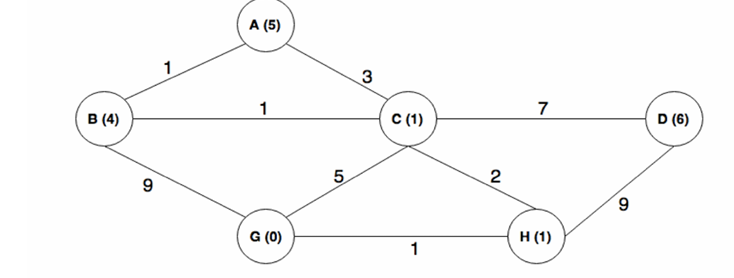

In [1]:

graph = {
    'A': [('B', 1) ,('C',3)],
    'B': [('A', 1), ('C', 1), ('G', 9)],
    'C': [('G', 5), ('H', 2), ('D',7)],
    'D': [('C',7), ('H',9)],
    'G': [('B', 9), ('C', 5)],
    'H': [('C', 2), ('D', 9), ('G',1)]
}

In [ ]:
H_table = {
    'A': 5,
    'B': 4,
    'C': 1,
    'D': 6,
    'H': 1,
    'G': 0
}

In [ ]:
def path_f_cost(path):
    g_cost = 0
    for (node, cost ) in path:
        g_cost += cost

    last_node = path[-1][0]  # الحصول على آخر عقدة
    h_cost = H_table[last_node] # الحصول على تكلفة الدالة التقديرية
    f_cost = g_cost + h_cost  # حساب تكلفة f

    return f_cost,last_node

TESTING FUNCTION

In [ ]:
path= [('A',0),('B',0),('A',1)]
print(path_f_cost(path))

(6, 'A')


In [ ]:
path=[('A',0),('B',1),('C',1)]
print(path_f_cost(path))

(3, 'C')


In [ ]:
path=[('A',0),('B',1),('G',9)]
print(path_f_cost(path))

(10, 'G')


In [ ]:
path=[('A',0),('C',3),('G',1)]
print(path_f_cost(path))

(4, 'G')


In [ ]:
path=[('A',0),('C',3),('H',2)]
print(path_f_cost(path))

(6, 'H')


In [ ]:
path=[('A',0),('C',3),('D',7)]
print(path_f_cost(path))

(16, 'D')


In [ ]:
path=[('A',0),('B',1),('C',1),('H',2)]
print(path_f_cost(path)) ###

(5, 'H')


**A*Search**




In [ ]:
def a_star_search(graph, start, goal):
  visited = []
  queue=[[(start,0)]]
  while queue:
    queue.sort(key = path_f_cost)
    path = queue.pop(0)
    node = path[-1][0]
    if node in visited:
      continue
    visited.append(node)
    if node == goal:
      return path

    else:
      adjacent_nodes = graph.get(node, [])
      for (node2,cost) in adjacent_nodes:
           new_path = path.copy()
           new_path.append((node2,cost))
           queue.append(new_path)

In [ ]:
solution = a_star_search( graph , 'A', 'G')
print('Solution is:', solution)
print('Cost of solution is:', path_f_cost(solution)[0])

Solution is: [('A', 0), ('C', 3), ('H', 2), ('G', 1)]
Cost of solution is: 6
